In [2]:
## conda activate gpy_torch_env
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import tqdm
import torch 
from torch.autograd.functional import jacobian
from torch.distributions.multivariate_normal import MultivariateNormal
import gpytorch
import pyro
from pyro.infer import MCMC, NUTS
import pyro.distributions as dist
from scipy.linalg import eigh
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp
from scipy.stats import norm, multivariate_normal, invgamma, uniform
from scipy import interpolate




## Forward Model

Solve spring problem
\begin{align}
        M x'' + C x' + K x = 0   
    \end{align}

where $M$ is a matrix with the mass values, $C$ is the matrix of dashpot coefficients, and $K$ is the matrix of stiffness parameters. Note that this problem is actually non-identifiable, as the problem can be written as
\begin{align}
        x'' + \tilde{C} x' + \tilde{K} x = 0   
    \end{align}
    where $\tilde{C} = M^{-1}C$ and $\tilde{K} = M^{-1}K$. Thus, we will assume that $M$ is known, but that $C$ and $K$ may be unknown (or convert the system to the second system).



We require the solution of the sensitivity system:
\begin{align}
    \frac{d\chi}{dt} &= \frac{\partial g}{\partial y} \frac{\partial y}{\partial \theta} + \frac{\partial g}{\partial \theta} \\
    &= \frac{\partial g}{\partial u} \chi + \frac{\partial g}{\partial \theta}
    \end{align}
where $\frac{\partial g}{\partial u}$ is the Jacobian of the system, $\bm{\chi}$ is the sensitivity of the states with respect to the parameters, and $\frac{\partial g}{\partial \bm{\theta}}$ are the derivatives with respect to the right hand side expressions. Again for numerical purposes we construct the relative variables for our system, i.e. scaled by the population $N$.

In [3]:
from Two_Spring_Model import call_model

In [4]:
# torch.manual_seed(20)
## design variables 
n_grid = 200
t0, tf = 0.0, 10.0
dt = 0.05
tvals = torch.linspace(t0,tf,n_grid)
## true parameter 
# theta_true = torch.tensor(np.log([2.6,0.6,1.2,1.1,4.1,0.4,2.0,0.5]), requires_grad=False)
m1_true = 5.0
m2_true = 10.0

k1 = 20.0
k2 = 10.0
c1 = 3.5
c2 = 2.5
F0 = 25.0
omega_f = 5.0


# theta_true = torch.log(torch.tensor([k1,c1,k2,c2], requires_grad=False))
theta_true = torch.tensor([k1,c1,k2,c2], requires_grad=False)

F_true = np.array([F0,omega_f])
# F_approx = np.array([12,4.2])
F_approx = np.array([F0,omega_f])

x_true = call_model(theta_true,tvals,F_true)
x_approx = call_model(theta_true,tvals,F_approx)
# c_vals = 2.1 * np.ones(N)



# Multivariate Orthogonal GP

In [5]:
J=2

def computeJitter(Cmat, target_min_eigval, min_jitter):
    eigvals = torch.linalg.eigvalsh(Cmat)
    lambda_min = eigvals.min()
    required_jitter = torch.clamp(target_min_eigval - lambda_min, min=min_jitter).item()
    return required_jitter  

def compute_jacobian(theta,x):
        # Break Jacobian into numerical solution of system 
        (x1,x2,v1,v2,
        x1k1,x2k1,v1k1,v2k1,
        x1c1,x2c1,v1c1,v2c1,
        x1k2,x2k2,v1k2,v2k2,
        x1c2,x2c2,v1c2,v2c2)= call_model(theta,x,F_approx)
        # f1,f2,s11,s21,s12,s22 = solution.T
        # print(np.size(Smu,axis=0))
        jac = torch.empty(J,np.size(x1,axis=0),4)
        jac[0,:,0] = x1k1
        jac[0,:,1] = x1c1
        jac[0,:,2] = x1k2
        jac[0,:,3] = x1c2

        jac[1,:,0] = x2k1
        jac[1,:,1] = x2c1
        jac[1,:,2] = x2k2
        jac[1,:,3] = x2c2

        # jac = torch.empty(4,np.size(x1,axis=0),J)
        # jac[0,:,0] = x1k1
        # jac[1,:,0] = x1c1
        # jac[2,:,0] = x1k2
        # jac[3,:,0] = x1c2

        # jac[0,:,1] = x2k1
        # jac[1,:,1] = x2c1
        # jac[2,:,1] = x2k2
        # jac[3,:,1] = x2c2

        # jac = torch.empty(J,4,np.size(x1,axis=0))
        # jac[0,0,:] = x1k1
        # jac[0,1,:] = x1c1
        # jac[0,2,:] = x1k2
        # jac[0,3,:] = x1c2

        # jac[1,0,:] = x2k1
        # jac[1,1,:] = x2c1
        # jac[1,2,:] = x2k2
        # jac[1,3,:] = x2c2

        # Definition from GPT: Nt by J by num_par
        # jac = torch.empty(np.size(x1,axis=0), J, 4)
        # jac[:, 0, 0] = x1k1
        # jac[:, 0, 1] = x1c1
        # jac[:, 0, 2] = x1k2
        # jac[:, 0, 3] = x1c2

        # jac[:, 1, 0] = x2k1
        # jac[:, 1, 1] = x2c1
        # jac[:, 1, 2] = x2k2
        # jac[:, 1, 3] = x2c2



         
        return jac  


class MultivariateOrthogonalKernel(torch.nn.Module):
    def __init__(self, C_func, call_model, gamma=1e-1, min_jitter=1e-8, max_tries=6):
        super().__init__()
        self.J = C_func.num_tasks
        self.C_func = C_func
        self.fmodel = call_model
        self.gamma = gamma
        self.min_jitter = min_jitter
        self.max_tries = max_tries

    def forward(self, x, theta, xvol=None, return_lazy=True):
        n = x.shape[0]
        if xvol is None:
            xvol = 1.0 / n

        # m = n * J output dimension
        m = n * self.J
        
        # 1) Lazy covariance C: (m, m)
        C = self.gamma * self.C_func(x)  # keep lazy

        # 2) Jacobian Jmat: (m, P)
        J_theta_x = compute_jacobian(theta, x)  # (n, J, P)
        # Jmat = J_theta_x.reshape(m, -1)
        # FROM GPT
        Jmat = J_theta_x.reshape(m, 4)

        # 3) CJ and H
        CJ = C @ Jmat                          # (m, P)

     
        
        H = (xvol * xvol) * (Jmat.T @ CJ)      # (P, P)

        P = H.shape[0]
        I_P = torch.eye(P, device=H.device, dtype=H.dtype)

        # 4) Cholesky with escalating jitter
        jitter = self.min_jitter
        for _ in range(self.max_tries):
            try:
                L = torch.linalg.cholesky(H + jitter * I_P)
                break
            except RuntimeError:
                jitter *= 10.0
        else:
            raise RuntimeError("Failed to Cholesky-factor H even after jitter escalation.")

        # 5) Projection term: (xvol*CJ) H^{-1} (xvol*CJ)^T
        h = xvol * CJ                          # (m, P)
        X = torch.cholesky_solve(h.T, L)       # (P, m)
        proj = h @ X                           # (m, m)

        # 6) C_delta = C - proj
        C_delta = C - proj

        if return_lazy and hasattr(C_delta, "to_dense"):
            # print('lazy')
            return C_delta

        # If you need dense
        if hasattr(C_delta, "to_dense"):
            C_delta = C_delta.to_dense()
            # print('dense')
        C_delta = 0.5 * (C_delta + C_delta.T)
        return C_delta

# Statistical Inference

In [6]:
## define orthogonal discrepancy prior 
data_seed = 325
torch.manual_seed(data_seed)
gamma_true = 0.1# was 0.01
bw_param_true = 0.8# Was 0.5
marg_kernel = gpytorch.kernels.RBFKernel()
marg_kernel.lengthscale = torch.tensor(bw_param_true)
marg_kernel.raw_lengthscale.requires_grad = False
## numerical stability 
target_min_eigval = 1e-6
min_jitter = 1e-10 

Cov_unc = gpytorch.kernels.MultitaskKernel(marg_kernel, num_tasks=J) ## eval -> nJ x nJ (need to reshape)
Cov_delta_theta = MultivariateOrthogonalKernel(Cov_unc, call_model, gamma=gamma_true, 
                                                    min_jitter=min_jitter)
# Cov_delta_theta = MultivariateOrthogonalKernel(Cov_unc, call_model, gamma=gamma_true, 
                                                    # target_min_eigval=target_min_eigval, min_jitter=min_jitter)
C_delta_theta_true_xobs_flat = Cov_delta_theta(tvals, theta_true)

# delta_ortho_theta_true_prior = MultivariateNormal(torch.zeros(n_grid * J), C_delta_theta_true_xobs_flat)

## add jitter for numerical stabality in unconstrained case
C_x_flat = gamma_true*Cov_unc(tvals).evaluate()
jitter = computeJitter(C_x_flat, target_min_eigval, min_jitter)
C_x_flat = C_x_flat + jitter*torch.eye(n_grid*J)
# delta_unconstr_prior = MultivariateNormal(torch.zeros(n_grid * J), C_x_flat)

## compare to unrestricted prior  
# delta_orth_sample = delta_ortho_theta_true_prior.rsample((1,)).view(1, len(tvals), J)
# delta_uncon_sample =delta_unconstr_prior.rsample((1,)).view(1, len(tvals), J)
I_MV = torch.eye(n_grid * J)
jitter = computeJitter(C_x_flat, target_min_eigval, min_jitter)
L_MOP = torch.linalg.cholesky(C_delta_theta_true_xobs_flat)
# if int(info) == 0:
delta_orth_sample = (L_MOP @ torch.randn(n_grid * J)).view(n_grid, J).detach()


L_KOH = torch.linalg.cholesky(C_x_flat)
delta_uncon_sample = (L_KOH @ torch.randn(n_grid * J)).view(n_grid, J).detach()



c:\Users\colebanm\uq_disc\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
c:\Users\colebanm\uq_disc\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(


C:\Users\colebanm\AppData\Local\Temp\ipykernel_17940\4236715620.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  xi_true = f_true+delta_disc_true


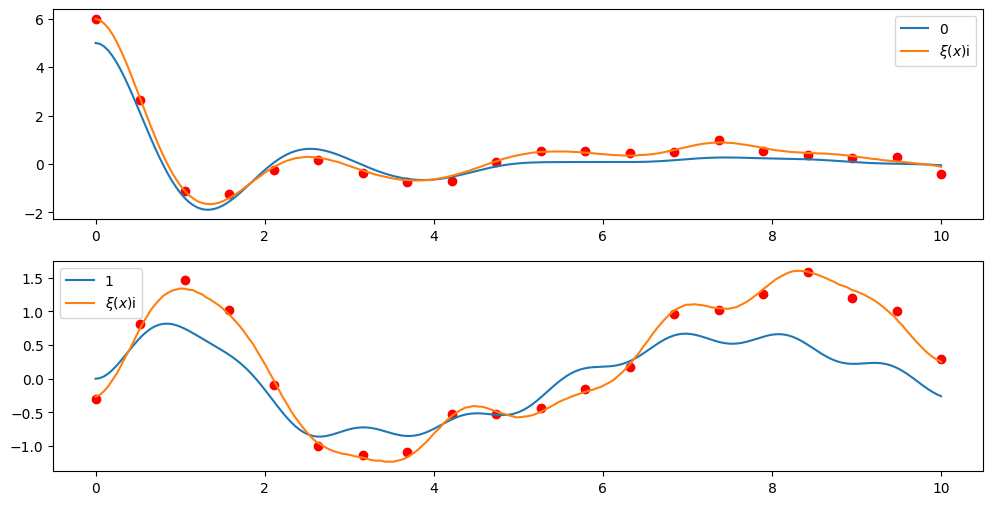

In [7]:
from scipy import interpolate
## observation model 
n_obs = 20
t_obs = torch.linspace(0.0, tvals[-1], n_obs)

## sample true discrepancy
# delta_disc_true = delta_uncon_sample.detach().numpy()#
delta_disc_true = delta_orth_sample.detach().numpy()
(x1,x2,v1,v2,
        x1k1,x2k1,v1k1,v2k1,
        x1c1,x2c1,v1c1,v2c1,
        x1k2,x2k2,v1k2,v2k2,
        x1c2,x2c2,v1c2,v2c2) = call_model(theta_true,tvals,F_true)


f_approx =  call_model(theta_true,tvals,F_approx)
f_true = torch.transpose(torch.reshape(torch.concat([x1,x2]),(2,len(x1))),0,1)
xi_true = torch.zeros((len(x1),J))
xi_true = f_true+delta_disc_true



## local interpolation from discretized function repreresentation
xi_1_interp = interpolate.interp1d(tvals.detach().numpy(), xi_true[:,0].detach().numpy())
xi_2_interp = interpolate.interp1d(tvals.detach().numpy(), xi_true[:,1].detach().numpy())

xi_obs = torch.cat((torch.from_numpy(xi_1_interp(t_obs.detach().numpy())).float().view(-1,1),
                    torch.from_numpy(xi_2_interp(t_obs.detach().numpy())).float().view(-1,1)), dim=-1)

# local interpolation from discretized function repreresentation
# xi_1_interp = interpolate.interp1d(tvals.detach().numpy(), xi_true[:,0].detach().numpy())

# xi_obs = (torch.from_numpy(xi_1_interp(t_obs.detach().numpy())).float().view(-1,1))

## iid measurement error 
sigma_e = 0.1
y_obs = xi_obs + torch.normal(0, sigma_e, size=(n_obs,J))
## plot optimally calibrated model + true phyiscal process, 
fig, ax = plt.subplots(2,1,figsize=(12,6))

for i in range(J):
        ax[i].plot(tvals.numpy(), f_approx[i,:].detach().numpy(), label=i)
        ax[i].plot(tvals.numpy(), xi_true[:, i].detach().numpy(), label=r'$\xi(x)$i')
        ax[i].scatter(t_obs.numpy(), y_obs[:, i].detach().numpy(), c="r")
        ax[i].legend()



## GLOABL OPTIMIZATION

In [8]:
print(theta_true)

tensor([20.0000,  3.5000, 10.0000,  2.5000])


In [9]:

LB = torch.tensor([1.0,0.1,1.0,0.1])
UB = torch.tensor([100.0,10.0,100.0,10.0])

print(LB)
print(theta_true)
print(UB)

tensor([1.0000, 0.1000, 1.0000, 0.1000])
tensor([20.0000,  3.5000, 10.0000,  2.5000])
tensor([100.,  10., 100.,  10.])


In [ ]:
from scipy.stats import qmc
sampler = qmc.Sobol(d=4, scramble=False)
sample = sampler.random_base2(m=5)
sample_scale = qmc.scale(sample,LB,UB)
print(np.shape(sample_scale))
print(sample_scale)
print(theta_true)

(2, 4)
[[ 1.          0.1         1.          0.1       ]
 [50.5         5.04999981 50.5         5.04999981]]
tensor([20.0000,  3.5000, 10.0000,  2.5000])


In [16]:
# from multi_eval_SIRV import run_parallel_grid_search_streaming
from multi_opt_2springs import run_save
data_flat = y_obs.transpose(1, 0).reshape(-1)

# Create several starting guesses
start_thetas = sample_scale
# bounds = list(zip(LB, UB))

bounds = (LB,UB)
# Run optimizations in parallel
f_load = run_save(start_thetas,data_flat,t_obs,F_true,10,bounds)





Run 0: success=True, fun=4.9315e+00, x=[12.41821421  1.51100927 13.84918691  3.37609432], nit=None
Run 1: success=True, fun=4.9315e+00, x=[12.41649765  1.50962607 13.85094585  3.37640557], nit=None
Saved compressed results to TwoSpring_optimization_results_MOPdisc_final_V1.npz
Saved JSON results to TwoSpring_optimization_results_MOPdisc_final_V1.json


In [19]:
data = np.load(f_load+".npz",allow_pickle=True)
results = data['results']
x0 = data['start_thetas']

In [20]:
f_vals = np.zeros((len(start_thetas)))
x_vals = np.zeros((len(start_thetas),len(UB)))
for i in range(len(start_thetas)):
    f_vals[i]     = results[i]['fun']
    x_vals[i,:]    = results[i]['x']


f_ids = np.argsort(f_vals)
f_sorted = f_vals[f_ids]
x_sorted = x_vals[f_ids,:]

f_vals = f_vals
f_sorted = f_sorted





# Statistical Inference

In [21]:
## FOR TWO SPRINGs
# Try defining an update-able discrepancy
target_min_eigval = 1e-6
min_jitter = 1e-10 
# marg_kernel = gpytorch.kernels.RBFKernel()
# marg_kernel.initialize(lengthscale=torch.tensor(bw_param_true))
# marg_kernel.raw_lengthscale.requires_grad = False   # freeze it if needed
GP_Cov_unc = gpytorch.kernels.MultitaskKernel(marg_kernel, num_tasks=J) ## eval -> nJ x nJ (need to reshape)
GP_Cov_unc.data_covar_module.initialize(lengthscale=torch.tensor(bw_param_true))
GP_Cov_unc.data_covar_module.raw_lengthscale.requires_grad = False
GP_Cov_MOP = MultivariateOrthogonalKernel(Cov_unc, call_model, gamma=gamma_true, 
                                                min_jitter=min_jitter)

In [22]:

## inference

def potential_fn_MOP(theta,GPtheta,GP_cov,s2):
    # Gaussian Process for discrepancy term
    gamma,bw = GPtheta
    GP_cov.C_func.data_covar_module.raw_lengthscale.copy_(torch.tensor([bw],dtype=torch.float32))
    # GP_cov.C_func.data_covar_module.raw_lengthscale.fill_(torch.float32(bw))
    GP_cov.gamma = gamma.to(torch.float32)

    theta_call = theta#torch.tensor([theta[0],np.log(c1),theta[1],np.log(c2)], requires_grad=False)

    # Gaussian Process for discrepancy term
    C_cov_1 = GP_cov(t_obs, theta_call)
    
    Cov = 0.5*(C_cov_1 + C_cov_1.T)  + (s2)*torch.eye(n_obs*J)

    # y = y_obs.reshape(-1)
    y = torch.transpose(y_obs,1,0).flatten()
    m = y.numel()
    I = torch.eye(m)

    Cov = Cov.to(torch.float32)
    I = I.to(torch.float32)

    L = torch.linalg.cholesky(Cov + jitter*I)
    # y_all = call_model(theta,t_obs,F_true)

    y_all = call_model(theta_call,t_obs,F_approx)

    # (x1,x2,v1,v2,
    #     x1k1,x2k1,v1k1,v2k1,
    #     x1c1,x2c1,v1c1,v2c1,
    #     x1k2,x2k2,v1k2,v2k2,
    #     x1c2,x2c2,v1c2,v2c2) = call_model(theta_call,t_obs,F_approx)



    # states = torch.transpose(torch.reshape(torch.concat([x1,x2]),(J,len(t_obs))),0,1)
    # f_x_flat = states.reshape(n_obs*J)
    # f_x_flat = states.reshape(-1)                # (m,)

    # states = torch.transpose(torch.reshape(torch.concat([x1,x2]),(J,len(t_obs))),1,1)
    states = y_all[0:J,:]
    f_x_flat = states.reshape(n_obs*J)
    f_x_flat = f_x_flat.to(torch.float32)
    
    # print("y dtype:", y_obs.dtype)
    # print("fx dtype:", f_x_flat.dtype)
    # print("L dtype:", L.dtype)

    # alpha = torch.cholesky_solve((y_obs.view(n_obs*J) - f_x_flat).unsqueeze(-1), L)
    # alpha = L.solve((y_obs.view(n_obs*J) - f_x_flat).unsqueeze(-1))
    alpha = L.solve((y - f_x_flat).unsqueeze(-1))

    logdet = 2*torch.sum(torch.log(torch.diagonal(L)))
    # quad = (y_obs.view(n_obs*J) - f_x_flat).unsqueeze(0) @ alpha
    quad = (y - f_x_flat).unsqueeze(0) @ alpha



    
    PD_value = -0.5*(quad.squeeze() + logdet + (n_obs*J)*np.log(2*np.pi))
    # SS = torch.sum((y_obs.view(n_obs*J)-f_x_flat)**2)
    SS = torch.sum((y-f_x_flat)**2)
    
    ## forward model 
    # f_x_flat = fmodel_MJC(x_obs, theta).view(n_obs*J)
    
    # plt.figure()
    # plt.plot(f_x_flat,label='simulator')
    # plt.plot(y,label='data')
    # plt.legend()
    # plt.show()

    ## posterior density (MJC: added try statement here because I kept getting non-SPD covariances)
    # try:
    #    post_density = dist.MultivariateNormal(f_x_flat, Cov)
    #    PD_value = post_density.log_prob(y_obs.view(n_obs*J)) # EQ 17 IN OUR METHODS
    #    SS = torch.sum((y_obs.view(n_obs*J)-f_x_flat)**2)
    # except:
    #    PD_value = torch.tensor(-torch.inf)
    #    SS = torch.inf
    return PD_value, SS




LOG2PI = np.log(2.0 * np.pi)
def mvn_log_prob_from_cholesky(y, mean, cov, I, jitter=1e-8, max_tries=6):
    """
    y, mean: (m,)
    cov: (m,m) dense
    I: (m,m) identity on correct device/dtype
    """
    r = (y - mean).reshape(-1, 1)  # (m,1)
    j = jitter
    for _ in range(max_tries):
        try:
            L = torch.linalg.cholesky(cov + j * I)
            break
        except RuntimeError:
            j *= 10.0
    else:
        return -torch.inf

    alpha = torch.cholesky_solve(r, L)           # (m,1)
    quad = (r.T @ alpha).squeeze()               # scalar
    logdet = 2.0 * torch.sum(torch.log(torch.diagonal(L)))
    m = y.numel()
    return -0.5 * (quad + logdet + m * LOG2PI)

def potential_fn_IND(theta,GPtheta,GP_cov,s2):
    # Gaussian Process for discrepancy term
    # Gaussian Process for discrepancy term
    gamma,bw = GPtheta
    GP_cov.data_covar_module.raw_lengthscale.fill_(float(bw))

    ## forward model 
    # f_x_flat = fmodel_MJC(x_obs, theta).view(n_obs*J)
    # y_all = call_model(theta,t_obs,F_true)
    theta_call = theta#torch.tensor([theta[0],np.log(c1),theta[1],np.log(c2)], requires_grad=False)
    y_all = call_model(theta_call,t_obs,F_approx)

    # states = torch.transpose(torch.reshape(y_all[0:J,:],(J,len(t_obs))),0,1)
    # f_x_flat = states.reshape(n_obs*J)
    # f_x_flat = states.reshape(-1)                # (m,)

    states = y_all[0:J,:]
    f_x_flat = states.reshape(n_obs*J)
    f_x_flat = f_x_flat.to(torch.float32)
    

    # y = y_obs.reshape(-1)
    y = torch.transpose(y_obs,1,0).flatten()
    m = y.numel()
    I = torch.eye(m)
    

    # plt.figure()
    # plt.plot(f_x_flat,label='simulator')
    # plt.plot(y,label='data')
    # plt.legend()
    # plt.show()

    # Covariance (materialize once)
    # If GP_cov(t_obs) is lazy, evaluate to dense here (one time)
    K = GP_cov(t_obs).evaluate()                 # (m,m) dense
    Cov = gamma * K + s2 * I

    Cov = Cov.to(torch.float32)
    I = I.to(torch.float32)
    # r = (y_obs2.view(n_obs*J)-f_x_flat)

    logp = mvn_log_prob_from_cholesky(y, f_x_flat, Cov, I)
    SS = torch.sum((y - f_x_flat) ** 2)
    return logp, SS



# def potential_fn_IND(theta,GPtheta,GP_cov,s2):
#     # Gaussian Process for discrepancy term
#     # Gaussian Process for discrepancy term
#     gamma,bw = GPtheta
#     GP_cov.data_covar_module.raw_lengthscale.copy_(torch.tensor([bw]))
#     # GP_cov.gamma = gamma
#     # Gaussian Process for discrepancy term
#     Cov = gamma*GP_cov(t_obs).evaluate() + (s2)*torch.eye(n_obs*J)
#     ## forward model 
#     # f_x_flat = fmodel_MJC(x_obs, theta).view(n_obs*J)
#     y_all = call_model(theta,t_obs,F_true)
#     states = torch.transpose(torch.reshape(y_all[0:4,:],(4,len(t_obs))),0,1)
#     f_x_flat = states.reshape(n_obs*J)
#     # print(f_x_flat)
#     ## posterior density 
#     post_density = dist.MultivariateNormal(f_x_flat, Cov)
#     SS = torch.sum((y_obs.view(n_obs*J)-f_x_flat)**2)
#     return post_density.log_prob(y_obs.view(n_obs*J)), SS
    
GPtheta = torch.tensor([0.1,1])
# print(potential_fn_IND(theta_true,GPtheta,GP_Cov_unc,sigma_e**2))

ll1,ss1 = potential_fn_MOP(theta_true,GPtheta,GP_Cov_MOP,0.01)
ll2,ss2 = potential_fn_IND(theta_true,GPtheta,GP_Cov_unc,0.01)

print(ll1,ss1,ll2,ss2)


tensor(4.1126, grad_fn=<MulBackward0>) tensor(8.8319) tensor(-112.3051, grad_fn=<MulBackward0>) tensor(8.8319)


In [23]:
## IID


def potential_fn_IID(theta,GPtheta,GP_cov,s2):

    y = y_obs.reshape(-1)
    m = y.numel()
    I = torch.eye(m)
    Cov = s2 * I
    Cov = Cov.to(torch.float32)
    I = I.to(torch.float32)

    L = torch.linalg.cholesky(Cov + jitter*I)
    # y_all = call_model(theta,t_obs,F_true)
    theta_call = theta#torch.tensor([theta[0],np.log(c1),theta[1],np.log(c2)], requires_grad=False)

    y_all = call_model(theta_call,t_obs,F_approx)

    states = torch.transpose(torch.reshape(y_all[0:J,:],(J,len(t_obs))),0,1)
    # f_x_flat = states.reshape(n_obs*J)
    f_x_flat = states.reshape(-1)                # (m,)
    f_x_flat = f_x_flat.to(torch.float32)
    # print("y dtype:", y_obs.dtype)
    # print("fx dtype:", f_x_flat.dtype)
    # print("L dtype:", L.dtype)

    Cov = s2 * I

    Cov = Cov.to(torch.float32)
    I = I.to(torch.float32)

    logp = mvn_log_prob_from_cholesky(y, f_x_flat, Cov, I)
    SS = torch.sum((y - f_x_flat) ** 2)
    return logp, SS



In [24]:
y_obs = y_obs.to(torch.float32)
t_obs = t_obs.to(torch.float32)

UB_MCMC = torch.tensor([100.0,5.0,100.0,5.0,1.5*gamma_true, 1.5*bw_param_true],dtype=torch.float32)
LB_MCMC = torch.tensor([1.0,0.1,1.0,0.1,0.5*gamma_true, 0.5*bw_param_true],dtype=torch.float32)

theta_all_true = torch.cat((theta_true,torch.tensor([gamma_true,bw_param_true])))

M = 10000
k0 = 2000


proposal_sd = 0.01 * (UB_MCMC - LB_MCMC)
covar = torch.diag(proposal_sd**2)

covar = covar.to(torch.float32)

print(theta_all_true)
print(torch.diag(covar))


tensor([20.0000,  3.5000, 10.0000,  2.5000,  0.1000,  0.8000])
tensor([9.8010e-01, 2.4010e-03, 9.8010e-01, 2.4010e-03, 1.0000e-06, 6.4000e-05])


In [25]:
data_flat = y_obs.transpose(1, 0).reshape(-1)

theta_L2_opt = x_sorted[0,:]
output = call_model(theta_L2_opt,t_obs,F_true)
output = output[0:J,:].flatten()
s20_init = torch.sum((data_flat - output) ** 2)/(len(y_obs.flatten()))
print(s20_init)
print(sigma_e)


tensor(0.1233, dtype=torch.float64)
0.1


In [ ]:
from AM_withGibbs import adaptive_metropolis_s2update


In [ ]:
n_MCMC=10
chain_IND_all = torch.empty((n_MCMC,len(theta_all_true),M))
chain_MOP_all = torch.empty((n_MCMC,len(theta_all_true),M))
s2chain_IND_all = torch.empty((n_MCMC,M))
s2chain_MOP_all = torch.empty((n_MCMC,M))

import pickle

for i in range(n_MCMC):
    par_init = torch.tensor(np.random.normal(theta_all_true,proposal_sd))
    print(par_init)
    chain_IND, lik_chain_IND,s2_IND = adaptive_metropolis_s2update(post_func=potential_fn_IND, theta0=par_init, k0=k0, M=M, covar=covar, UB=UB_MCMC, LB=LB_MCMC, GP_cov=GP_Cov_unc,s2_init=s20_init,n_obs=n_obs)
    print('IND complete',i)
    chain_MOP, lik_chain_MOP, s2_MOP = adaptive_metropolis_s2update(post_func=potential_fn_MOP,  theta0=par_init, k0=k0, M=M, covar=covar, UB=UB_MCMC, LB=LB_MCMC, GP_cov=GP_Cov_MOP,s2_init=s20_init,n_obs=n_obs)
    print('MOP complete',i)
    chain_IND_all[i,:,:] = chain_IND
    chain_MOP_all[i,:,:] = chain_MOP
    s2chain_IND_all[i,:] = s2_IND
    s2chain_MOP_all[i,:] = s2_MOP

    chain_results = {
    'tvals': tvals,
    't_obs': t_obs,
    'seed': data_seed,
    'obs': y_obs,
    'xi_true': xi_true,
    'xi_obs': xi_obs,
    'UB': UB_MCMC,
    'LB': LB_MCMC,
    'theta_all_true': theta_all_true,
    'chain_IND_all': chain_IND_all,
    'chain_MOP_all': chain_MOP_all,
    's2chain_IND_all': s2chain_IND_all,
    's2chain_MOP_all': s2chain_MOP_all,
    's20_init': s20_init,
    'x_sorted': x_sorted,
    'f_sorted': f_sorted
}
    with open('Spring_TwoMass_AMwithGibbs_10chain.pkl', 'wb') as f:
        pickle.dump(chain_results, f)







In [ ]:
# with open('Spring_2springs_MOPdisc_10chains.pkl', 'wb') as f:
#     pickle.dump(chain_results, f)

In [ ]:

which_chain = 2
chain_IND = chain_IND_all[which_chain,:,5000:]
chain_MOP = chain_MOP_all[which_chain,:,5000:]
param_names = ['k1','c1','k2','c2','gamma','bw']

print(torch.var(chain_IND,dim=1))
print(torch.var(chain_MOP,dim=1))


# Analyze the results
print(np.mean(chain_MOP[2,:].detach().numpy()))
# Plot the results
plt.rcParams['font.size'] = 9
plt.figure(figsize=(12, 16))

for i in range(len(param_names)):
    plt.subplot(3, 2, i+1)
    plt.hist(chain_IND[i,:].detach(), bins=30, density=True,color='r',alpha=0.3,label='KOH')
    plt.hist(chain_MOP[i,:].detach(), bins=30, density=True,color='c',alpha=0.3,label='Our Approach')
    # plt.hist(torch.exp(chain_iid[0,:].detach()), bins=30, density=True,color='b',alpha=0.3,label='iid')
    plt.axvline(theta_all_true[i], color='k', linestyle='--', label='True')
    plt.xlim((LB_MCMC[i],UB_MCMC[i]))
    plt.xlabel(param_names[i])
# plt.legend()


plt.show()




In [ ]:
# "a": theta_all_true[0].detach().clone(),
    # "v": theta_all_true[1].detach().clone(),
    # "mu": theta_all_true[2].detach().clone(),
    # "wr": theta_all_true[3].detach().clone(),
    # "wv": theta_all_true[4].detach().clone(),
    # "gam":theta_all_true[5].detach().clone(),
    # "bw": theta_all_true[6].detach().clone(),
burnin = 2000
samples_IND =  chain_IND_all[which_chain,:,burnin:]
samples_MOP = chain_MOP_all[which_chain,:,burnin:]

num_draws = min(300, samples_IND[0,:].shape[0])
idx = torch.randint(0, samples_IND[0,:].shape[0], (num_draws,))

posterior_state_IND = []
posterior_state_MOP = []
posterior_state_IND_disc = []
posterior_state_MOP_disc = []
disc_IND = []
disc_MOP = []

for i in idx:
    states_IND = call_model(samples_IND[:4,i].flatten(),tvals,F_true)
    posterior_state_IND.append(states_IND[0:J,:])
    states_MOP = call_model(samples_MOP[:4,i].flatten(),tvals,F_true)
    posterior_state_MOP.append(states_MOP[0:J,:])

    

    ## IND
    GP_Cov_unc.data_covar_module.raw_lengthscale.copy_(torch.tensor([samples_IND[5,i]]))
    C_x_IND = samples_IND[4,i]*GP_Cov_unc(tvals).evaluate() + s20_init*torch.eye(n_grid*J)
    jitter = computeJitter(C_x_IND, target_min_eigval, min_jitter)
    C_x_IND = C_x_IND + jitter*torch.eye(n_grid*J)
    L = torch.linalg.cholesky(C_x_IND + jitter * I_MV)
    temp_IND = (L @ torch.randn(n_grid * J)).view(n_grid, J).detach()
    disc_IND.append(temp_IND.T)


    ## MOP
    GP_Cov_MOP.C_func.data_covar_module.raw_lengthscale.copy_(torch.tensor([samples_MOP[5,i]]))
    GP_Cov_MOP.gamma = samples_MOP[4,i]
    C_delta_theta_true_xobs_flat = GP_Cov_MOP(tvals, samples_MOP[:4,i].flatten()) + s20_init*torch.eye(n_grid*J)
    I_MV = torch.eye(n_grid * J)
    jitter = computeJitter(C_delta_theta_true_xobs_flat, target_min_eigval, min_jitter)
    L = torch.linalg.cholesky(C_delta_theta_true_xobs_flat + jitter * I_MV)
    temp_MOP = (L @ torch.randn(n_grid * J)).view(n_grid, J).detach()
    disc_MOP.append(temp_MOP.T)

    posterior_state_IND_disc.append(states_IND[0:J,:]+temp_IND.T)
    posterior_state_MOP_disc.append(states_MOP[0:J,:]+temp_MOP.T)



posterior_state_IND = torch.stack(posterior_state_IND)
posterior_state_MOP = torch.stack(posterior_state_MOP)
disc_IND = torch.stack(disc_IND)
disc_MOP = torch.stack(disc_MOP)

posterior_state_IND_disc = torch.stack(posterior_state_IND_disc)
posterior_state_MOP_disc = torch.stack(posterior_state_MOP_disc)



x_mean_IND = posterior_state_IND.mean(dim=0)
x_lower_IND = posterior_state_IND.quantile(0.05, dim=0)
x_upper_IND = posterior_state_IND.quantile(0.95, dim=0)

x_mean_MOP = posterior_state_MOP.mean(dim=0)
x_lower_MOP = posterior_state_MOP.quantile(0.05, dim=0)
x_upper_MOP = posterior_state_MOP.quantile(0.95, dim=0)

x_mean_IND_disc = posterior_state_IND_disc.mean(dim=0)
x_lower_IND_disc = posterior_state_IND_disc.quantile(0.05, dim=0)
x_upper_IND_disc = posterior_state_IND_disc.quantile(0.95, dim=0)

x_mean_MOP_disc = posterior_state_MOP_disc.mean(dim=0)
x_lower_MOP_disc = posterior_state_MOP_disc.quantile(0.05, dim=0)
x_upper_MOP_disc = posterior_state_MOP_disc.quantile(0.95, dim=0)




In [ ]:
###############################
plt.figure(figsize=(12, 8))
plt.subplot(2,2,1)
plt.scatter(t_obs.numpy(), y_obs[:,0].numpy(), s=12, label="observations")
plt.plot(tvals.numpy(), xi_true[:,0].detach().numpy(), label="true sig + disc")
plt.plot(tvals.numpy(), x_mean_IND[0,:].detach().numpy(), label="IND mean",color='red')
plt.plot(tvals.numpy(), x_true[0,:],color='black')
plt.fill_between(
    tvals.numpy(),
    x_lower_IND[0,:].detach().numpy(),
    x_upper_IND[0,:].detach().numpy(),
    alpha=0.25,
    color='red',
    label="90% posterior band",
)
plt.xlabel("time")
plt.ylabel("displacement")
plt.legend()
plt.tight_layout()

plt.subplot(2,2,2)
plt.scatter(t_obs.numpy(), y_obs[:,0].numpy(), s=12, label="observations")
plt.plot(tvals.numpy(), xi_true[:,0].detach().numpy(), label="true sig + disc")
plt.plot(tvals.numpy(), x_mean_MOP[0,:].detach().numpy(), label="MOP mean",color='cyan')
plt.plot(tvals.numpy(), x_true[0,:],color='black')
plt.fill_between(
    tvals.numpy(),
    x_lower_MOP[0,:].detach().numpy(),
    x_upper_MOP[0,:].detach().numpy(),
    alpha=0.25,
    color='cyan',
    label="90% posterior band",
)
plt.xlabel("time")
plt.ylabel("displacement")
plt.legend()
plt.tight_layout()

plt.subplot(2,2,3)
plt.scatter(t_obs.numpy(), y_obs[:,1].numpy(), s=12, label="observations")
plt.plot(tvals.numpy(), xi_true[:,1].detach().numpy(), label="true sig + disc")
plt.plot(tvals.numpy(), x_mean_IND[1,:].detach().numpy(), label="IND mean",color='red')
plt.plot(tvals.numpy(), x_true[1,:],color='black')
plt.fill_between(
    tvals.numpy(),
    x_lower_IND[1,:].detach().numpy(),
    x_upper_IND[1,:].detach().numpy(),
    alpha=0.25,
    color='red',
    label="90% posterior band",
)
plt.xlabel("time")
plt.ylabel("displacement")
plt.legend()
plt.tight_layout()

plt.subplot(2,2,4)
plt.scatter(t_obs.numpy(), y_obs[:,1].numpy(), s=12, label="observations")
plt.plot(tvals.numpy(), xi_true[:,1].detach().numpy(), label="true sig + disc")
plt.plot(tvals.numpy(), x_mean_MOP[1,:].detach().numpy(), label="MOP mean",color='cyan')
plt.plot(tvals.numpy(), x_true[1,:],color='black')
plt.fill_between(
    tvals.numpy(),
    x_lower_MOP[1,:].detach().numpy(),
    x_upper_MOP[1,:].detach().numpy(),
    alpha=0.25,
    color='cyan',
    label="90% posterior band",
)
plt.xlabel("time")
plt.ylabel("displacement")
plt.legend()
plt.tight_layout()


plt.show()

In [ ]:
###############################
plt.figure(figsize=(12, 8))
plt.subplot(2,2,1)
plt.scatter(t_obs.numpy(), y_obs[:,0].numpy(), s=12, label="observations")
plt.plot(tvals.numpy(), xi_true[:,0].detach().numpy(), label="true sig + disc")
plt.plot(tvals.numpy(), x_mean_IND_disc[0,:].detach().numpy(), label="IND mean",color='red')
plt.plot(tvals.numpy(), x_true[0,:],color='black')
plt.fill_between(
    tvals.numpy(),
    x_lower_IND_disc[0,:].detach().numpy(),
    x_upper_IND_disc[0,:].detach().numpy(),
    alpha=0.25,
    color='red',
    label="90% posterior band",
)
plt.xlabel("time")
plt.ylabel("displacement")
plt.legend()
plt.tight_layout()

plt.subplot(2,2,2)
plt.scatter(t_obs.numpy(), y_obs[:,0].numpy(), s=12, label="observations")
plt.plot(tvals.numpy(), xi_true[:,0].detach().numpy(), label="true sig + disc")
plt.plot(tvals.numpy(), x_mean_MOP_disc[0,:].detach().numpy(), label="MOP mean",color='cyan')
plt.plot(tvals.numpy(), x_true[0,:],color='black')
plt.fill_between(
    tvals.numpy(),
    x_lower_MOP_disc[0,:].detach().numpy(),
    x_upper_MOP_disc[0,:].detach().numpy(),
    alpha=0.25,
    color='cyan',
    label="90% posterior band",
)
plt.xlabel("time")
plt.ylabel("displacement")
plt.legend()
plt.tight_layout()

plt.subplot(2,2,3)
plt.scatter(t_obs.numpy(), y_obs[:,1].numpy(), s=12, label="observations")
plt.plot(tvals.numpy(), xi_true[:,1].detach().numpy(), label="true sig + disc")
plt.plot(tvals.numpy(), x_mean_IND_disc[1,:].detach().numpy(), label="IND mean",color='red')
plt.plot(tvals.numpy(), x_true[1,:],color='black')
plt.fill_between(
    tvals.numpy(),
    x_lower_IND_disc[1,:].detach().numpy(),
    x_upper_IND_disc[1,:].detach().numpy(),
    alpha=0.25,
    color='red',
    label="90% posterior band",
)
plt.xlabel("time")
plt.ylabel("displacement")
plt.legend()
plt.tight_layout()

plt.subplot(2,2,4)
plt.scatter(t_obs.numpy(), y_obs[:,1].numpy(), s=12, label="observations")
plt.plot(tvals.numpy(), xi_true[:,1].detach().numpy(), label="true sig + disc")
plt.plot(tvals.numpy(), x_mean_MOP_disc[1,:].detach().numpy(), label="MOP mean",color='cyan')
plt.plot(tvals.numpy(), x_true[1,:],color='black')
plt.fill_between(
    tvals.numpy(),
    x_lower_MOP_disc[1,:].detach().numpy(),
    x_upper_MOP_disc[1,:].detach().numpy(),
    alpha=0.25,
    color='cyan',
    label="90% posterior band",
)
plt.xlabel("time")
plt.ylabel("displacement")
plt.legend()
plt.tight_layout()


plt.show()